# Fraud Detection in credit card transactions

## Project goal
The goal is to build and compare machine learning models for detecting fraudulent credit card transactions.

This is a highly imbalanced binary classification problem: fraudulent operations make up only a very small fraction of all transactions. This issue is dealt with during the project and the respective results are shown.

## Main steps
1. Load and inspect the dataset  
2. Perform exploratory data analysis  
3. Prepare the data for modeling  
4. Train and evaluate several models  
5. Compare their performance on the fraud detection task

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

## Data loading

In [2]:
df = pd.read_csv("creditcard.csv")[:-1]
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284806 entries, 0 to 284805
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284806 non-null  float64
 1   V1      284806 non-null  float64
 2   V2      284806 non-null  float64
 3   V3      284806 non-null  float64
 4   V4      284806 non-null  float64
 5   V5      284806 non-null  float64
 6   V6      284806 non-null  float64
 7   V7      284806 non-null  float64
 8   V8      284806 non-null  float64
 9   V9      284806 non-null  float64
 10  V10     284806 non-null  float64
 11  V11     284806 non-null  float64
 12  V12     284806 non-null  float64
 13  V13     284806 non-null  float64
 14  V14     284806 non-null  float64
 15  V15     284806 non-null  float64
 16  V16     284806 non-null  float64
 17  V17     284806 non-null  float64
 18  V18     284806 non-null  float64
 19  V19     284806 non-null  float64
 20  V20     284806 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284806.000000,284806.000000,2.848060e+05,284806.000000,284806.000000,2.848060e+05,284806.000000,284806.000000,284806.000000,284806.000000,...,2.848060e+05,284806.000000,284806.000000,2.848060e+05,284806.000000,284806.000000,2.848060e+05,2.848060e+05,284806.000000,284806.000000
mean,94813.585781,0.000002,6.661845e-07,-0.000002,0.000002,4.404991e-08,0.000002,-0.000006,0.000001,-0.000002,...,-9.166146e-07,-0.000002,-0.000001,-3.088902e-08,0.000002,0.000003,8.480540e-09,-4.792355e-08,88.349168,0.001727
std,47488.004530,1.958699,1.651311e+00,1.516257,1.415871,1.380249e+00,1.332273,1.237092,1.194355,1.098634,...,7.345251e-01,0.725702,0.624461,6.056481e-01,0.521278,0.482225,4.036332e-01,3.300838e-01,250.120432,0.041527
min,0.000000,-56.407510,-7.271573e+01,-48.325589,-5.683171,-1.137433e+02,-26.160506,-43.557242,-73.216718,-13.434066,...,-3.483038e+01,-10.933144,-44.807735,-2.836627e+00,-10.295397,-2.604551,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.250000,-0.920374,-5.985522e-01,-0.890368,-0.848642,-6.915995e-01,-0.768296,-0.554080,-0.208628,-0.643098,...,-2.283974e-01,-0.542351,-0.161846,-3.545895e-01,-0.317142,-0.326979,-7.083961e-02,-5.295995e-02,5.600000,0.000000
50%,84691.500000,0.018109,6.549621e-02,0.179846,-0.019845,-5.433621e-02,-0.274186,0.040097,0.022358,-0.051429,...,-2.945020e-02,0.006781,-0.011196,4.097671e-02,0.016596,-0.052134,1.342243e-03,1.124381e-02,22.000000,0.000000
75%,139320.000000,1.315645,8.037257e-01,1.027198,0.743348,6.119267e-01,0.398567,0.570426,0.327346,0.597140,...,1.863701e-01,0.528548,0.147641,4.395270e-01,0.350716,0.240955,9.104579e-02,7.828043e-02,77.160000,0.000000
max,172788.000000,2.454930,2.205773e+01,9.382558,16.875344,3.480167e+01,73.301626,120.589494,20.007208,15.594995,...,2.720284e+01,10.503090,22.528412,4.584549e+00,7.519589,3.517346,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.isna()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284801,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
284802,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
284803,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
284804,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
df.dropna()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0


### Cool! We have no missing values, which means we can jump straight into the EDA

## Initial data inspection
The dataset contains transaction-level information. Most predictors are numerical, and the target variable is `Class`, where:
- `0` means a legitimate transaction,
- `1` means a fraudulent transaction.

In [7]:
class_counts = df["Class"].value_counts()
class_counts

Class
0    284314
1       492
Name: count, dtype: int64

In [8]:
fraud_ratio = df["Class"].mean()
print(f"Fraud ratio: {fraud_ratio:.6f} ({fraud_ratio*100:.4f}%)")

Fraud ratio: 0.001727 (0.1727%)


### The imbalance between fraudulent and non-fradulent transactions is very big, which means we should deal with them separately for further analysis

In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

### Let's check the features whether they are continuous or categorical

In [10]:
def classify_feature(df, col):
    unique_ratio = df[col].nunique() / len(df)

    if unique_ratio < 0.01:
        return "categorical"
    elif unique_ratio < 0.1:
        return "maybe categorical"
    else:
        return "continuous"

In [11]:
for c in list(df.columns):
    print(classify_feature(df, c))

continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
continuous
categorical


### Every non-target feature is continuous, which makes further analysis much easier

## EDA
At this stage, the distributions of the predictors are compared for legitimate and fraudulent transactions.

The goal of this analysis is to understand whether the classes differ in their feature distributions and whether the dataset contains signals that may help a model distinguish fraud from non-fraud transactions.

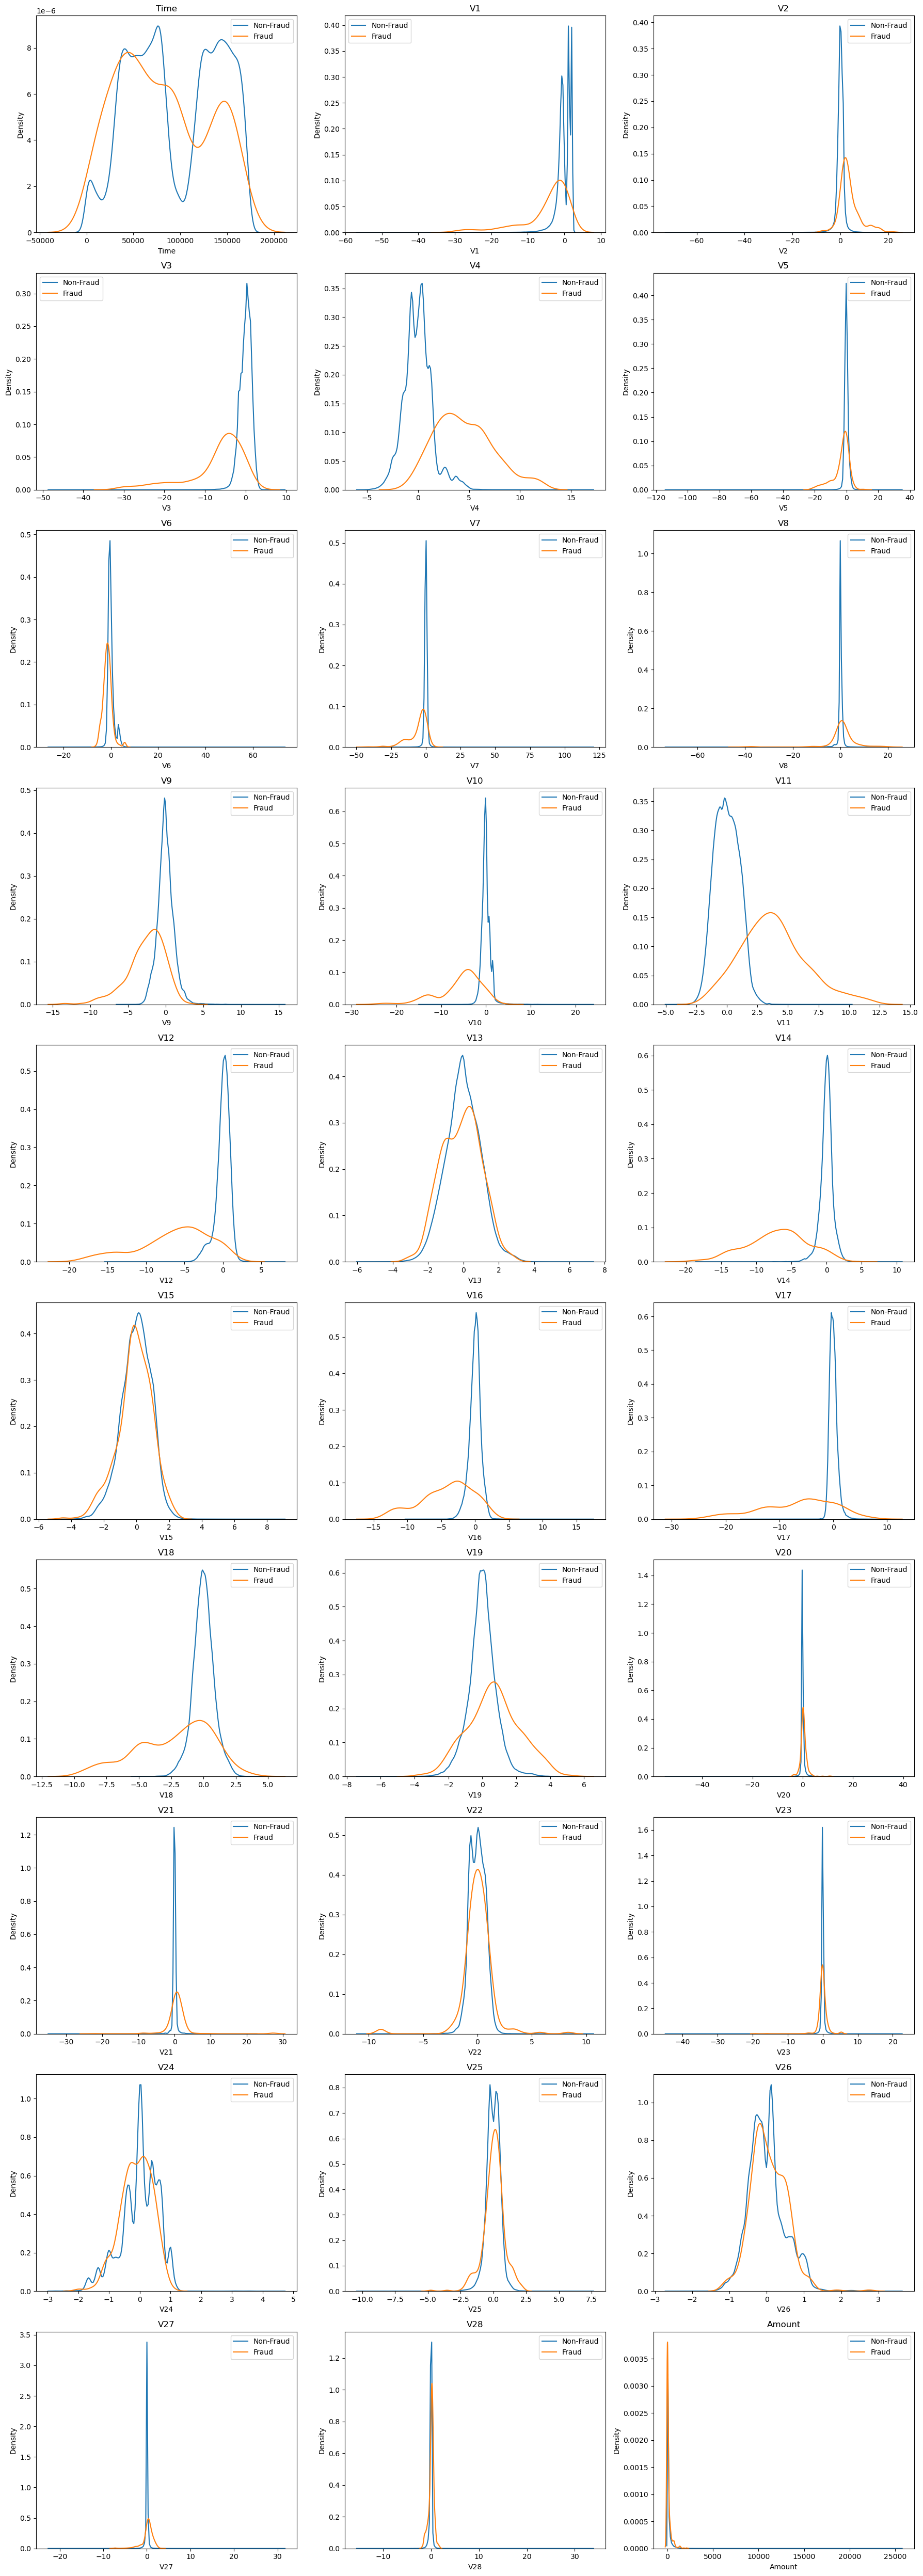

In [12]:
feature_cols = [col for col in df.columns if col != 'Class']

n_col = 3
n_row = math.ceil(len(feature_cols) / n_col)
plt.figure(figsize=(18, 5 * n_row))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_row, n_col, i)

    sns.kdeplot(
        data=df[df['Class'] == 0],
        x=col,
        label='Non-Fraud',
        fill=False
    )
    sns.kdeplot(
        data=df[df['Class'] == 1],
        x=col,
        label='Fraud',
        fill=False
    )

    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

The distribution plots show that several features differ substantially between fraudulent and non-fraudulent transactions. In particular, some components appear to have noticeably shifted distributions for the fraud class.

This suggests that the dataset contains meaningful predictive structure and is suitable for classification modeling.

The original `Amount` feature is highly skewed, with many small transactions and a long right tail.

To make this variable easier to analyze and more stable for some models, a logarithmic transformation is applied:
$$
\text{LogAmount} = \log(1 + \text{Amount})
$$

This transformation compresses extreme values while preserving the overall ordering of transaction sizes.

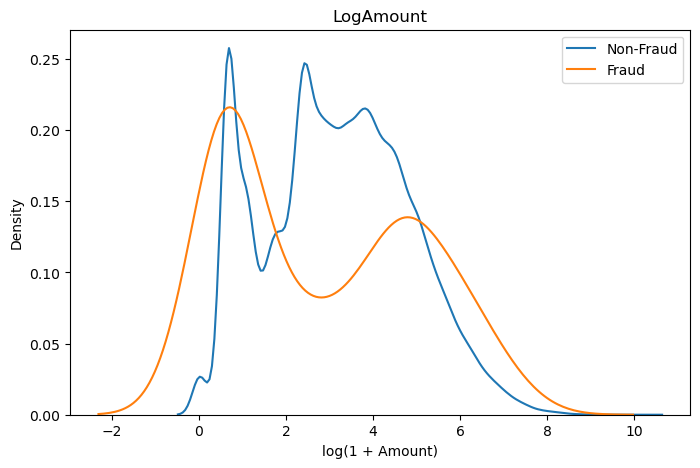

In [13]:
df['LogAmount'] = np.log1p(df['Amount'])

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df['Class'] == 0], x='LogAmount', label='Non-Fraud', bw_adjust=1.2)
sns.kdeplot(data=df[df['Class'] == 1], x='LogAmount', label='Fraud', bw_adjust=1.2)
plt.title('LogAmount')
plt.xlabel('log(1 + Amount)')
plt.ylabel('Density')
plt.legend()
plt.show()

To better understand which variables are most strongly associated with fraud, the correlation of each feature with the target variable is examined.
Although correlation does not fully capture nonlinear relationships, it provides a useful first approximation of which features may be especially informative for classification.

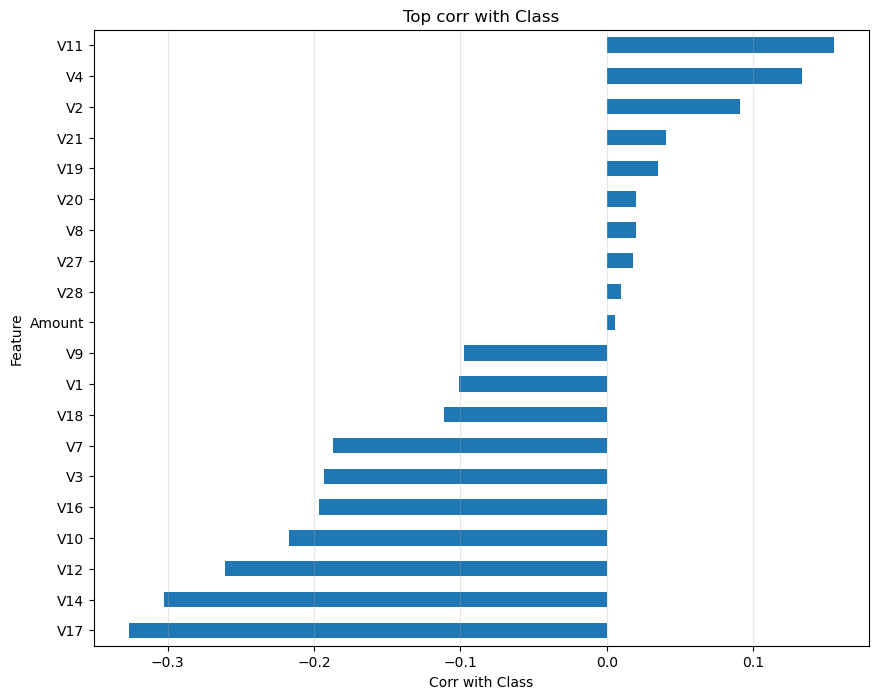

In [14]:
corr_with_target = df.corr(numeric_only=True)['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
pd.concat([corr_with_target.head(10), corr_with_target.tail(10)]).plot(kind='barh')
plt.title('Top corr with Class')
plt.xlabel('Corr with Class')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [15]:
corr_df = df.corr(numeric_only=True)['Class'].drop('Class').sort_values(key=lambda x: x, ascending=False).reset_index()
corr_df.columns = ['feature', 'corr']
corr_df.head(15).style.background_gradient(cmap='coolwarm')

,feature,corr
0,V11,0.154876
1,V4,0.133447
2,V2,0.091289
3,V21,0.040413
4,V19,0.034783
5,V20,0.020090
6,V8,0.019875
7,V27,0.017580
8,V28,0.009536
9,Amount,0.005632


## Boxplots for key interpretable variables

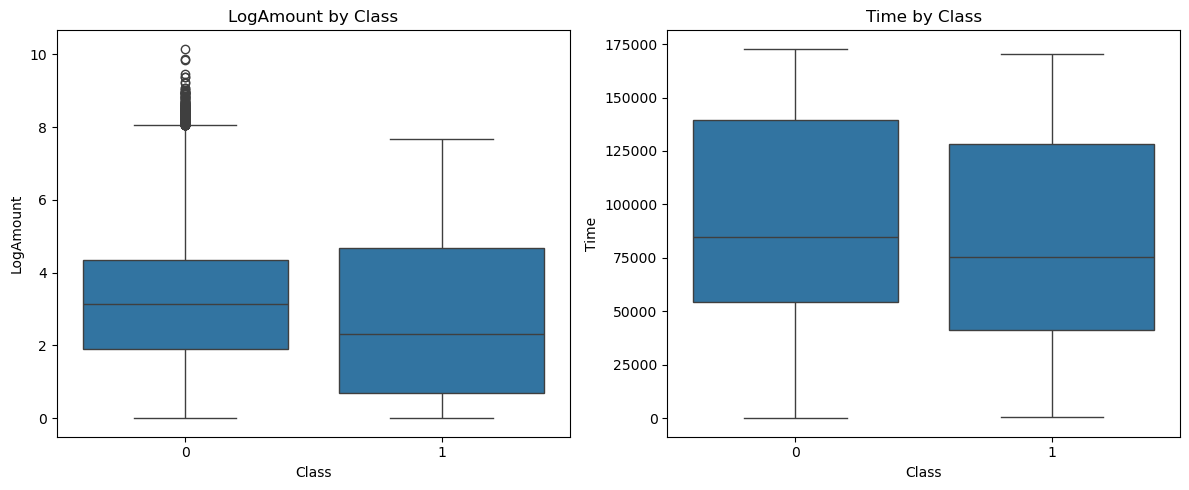

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Class', y='LogAmount', data=df)
plt.title('LogAmount by Class')
plt.xlabel('Class')
plt.ylabel('LogAmount')

plt.subplot(1, 2, 2)
sns.boxplot(x='Class', y='Time', data=df)
plt.title('Time by Class')
plt.xlabel('Class')
plt.ylabel('Time')

plt.tight_layout()
plt.show()

## EDA summary
The exploratory analysis shows that:
- the dataset is highly imbalanced,
- all predictors are numerical,
- several features differ substantially between fraudulent and legitimate transactions,
- the transformed transaction amount is easier to interpret than the raw amount.

Overall, the dataset appears well-suited for fraud detection modeling.

## Data preprocessing

In [17]:
df = df.drop(columns=['Amount'])

In [18]:
X = df.drop(columns=['Class'])
y = df['Class']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
def plot_pr_curve(y_true, y_proba, model_name='Model'):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(8, 5))
    plt.plot(recall, precision, label=f'{model_name} (PR-AUC = {pr_auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve: {model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Logistic Regression

In [21]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [22]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

print("PR-AUC CV scores:", scores)
print("Mean PR-AUC:", scores.mean())
print("PR-AUC:", average_precision_score(y_test, y_proba))


PR-AUC CV scores: [0.75869701 0.70192194 0.77160854 0.79038117 0.77358622]
Mean PR-AUC: 0.7592389770755019
PR-AUC: 0.7117743214328116


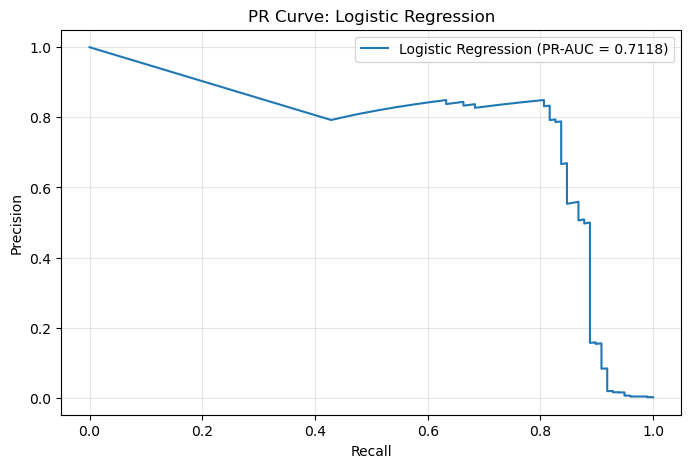

In [25]:
plot_pr_curve(y_test, y_proba, model_name='Logistic Regression')

LogReg achieves a high recall on the fraud class, which means that it is able to detect most fraudulent transactions. However, its precision is very low, indicating a large number of false positives.

## CatBoost

In [26]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='PRAUC',
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    verbose=100
)

In [27]:
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

0:	learn: 0.9777657	test: 0.9702760	best: 0.9702760 (0)	total: 88ms	remaining: 43.9s
100:	learn: 0.9997040	test: 0.9832570	best: 0.9837567 (18)	total: 4.28s	remaining: 16.9s
200:	learn: 0.9998675	test: 0.9831063	best: 0.9837640 (159)	total: 8.23s	remaining: 12.2s
300:	learn: 0.9999448	test: 0.9817330	best: 0.9837640 (159)	total: 12s	remaining: 7.91s
400:	learn: 0.9999783	test: 0.9805868	best: 0.9837640 (159)	total: 15.6s	remaining: 3.85s
499:	learn: 0.9999833	test: 0.9801369	best: 0.9837640 (159)	total: 19s	remaining: 0us

bestTest = 0.9837640057
bestIteration = 159

Shrink model to first 160 iterations.


In [28]:
cat_cv_scores = cross_val_score(
    cat_model,
    X_train,
    y_train,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

0:	learn: 0.9725093	total: 98.4ms	remaining: 49.1s
0:	learn: 0.9685692	total: 97.4ms	remaining: 48.6s
0:	learn: 0.9700246	total: 131ms	remaining: 1m 5s
0:	learn: 0.9718137	total: 132ms	remaining: 1m 5s
0:	learn: 0.9731158	total: 147ms	remaining: 1m 13s
100:	learn: 0.9998233	total: 8.09s	remaining: 32s
100:	learn: 0.9997688	total: 8.21s	remaining: 32.4s
100:	learn: 0.9997902	total: 9.53s	remaining: 37.7s
100:	learn: 0.9997877	total: 9.53s	remaining: 37.6s
100:	learn: 0.9998195	total: 9.59s	remaining: 37.9s
200:	learn: 0.9999010	total: 17.4s	remaining: 25.9s
200:	learn: 0.9998876	total: 17.4s	remaining: 25.9s
200:	learn: 0.9998812	total: 18.5s	remaining: 27.5s
200:	learn: 0.9999013	total: 18.5s	remaining: 27.6s
200:	learn: 0.9998968	total: 18.7s	remaining: 27.9s
300:	learn: 0.9999714	total: 26.4s	remaining: 17.5s
300:	learn: 0.9999724	total: 26.6s	remaining: 17.6s
300:	learn: 0.9999652	total: 27.5s	remaining: 18.2s
300:	learn: 0.9999728	total: 27.5s	remaining: 18.2s
300:	learn: 0.9999674

In [29]:
print(classification_report(y_test, y_pred_cat))
print("PR-AUC:", average_precision_score(y_test, y_proba_cat))
print("PR-AUC CV scores:", cat_cv_scores)
print("Mean PR-AUC:", cat_cv_scores.mean())

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.89      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.94      0.80     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.7529368899595703
PR-AUC CV scores: [0.84510816 0.81551197 0.84435678 0.82017348 0.85332946]
Mean PR-AUC: 0.835695970319497


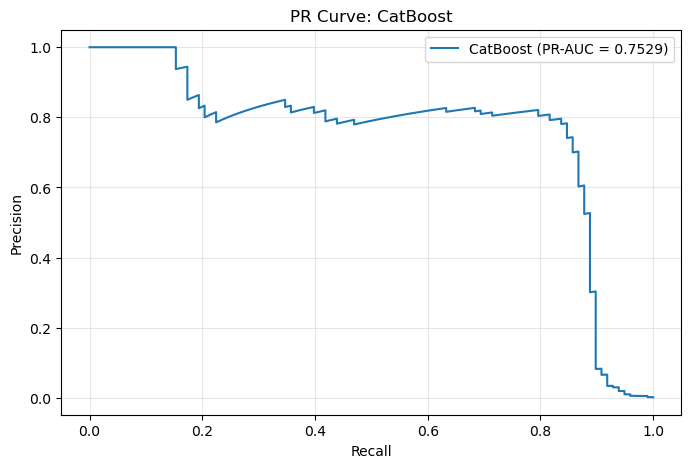

In [30]:
plot_pr_curve(y_test, y_proba_cat, model_name='CatBoost')

CatBoost significantly improves the overall quality of fraud detection compared to Logistic Regression. The model achieves a much better balance between precision and recall, while also increasing PR-AUC.

## XGBoost

In [31]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [32]:
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [33]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

In [34]:
print(classification_report(y_test, y_pred_xgb))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb))
print("PR-AUC CV scores:", xgb_cv_scores)
print("Mean PR-AUC:", xgb_cv_scores.mean())

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.8755909237962625
PR-AUC CV scores: [0.85848242 0.8303943  0.84684263 0.82853657 0.86654296]
Mean PR-AUC: 0.8461597736180083


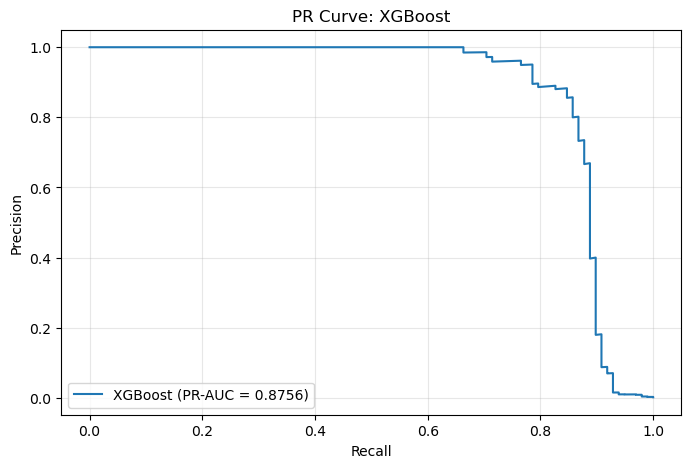

In [35]:
plot_pr_curve(y_test, y_proba_xgb, model_name='XGBoost')

XGBoost delivers the best PR-AUC among the classical ML models considered in this project. Compared to CatBoost, it shows slightly higher precision and slightly lower recall, which means it is somewhat more conservative in labeling transactions as fraudulent. Overall, it provides the strongest ranking performance and the best final trade-off among the tested non-neural approaches.

## Neural network approach (extension)
As an additional experiment, a feedforward neural network in PyTorch is implemented for the same fraud detection task. It will be shortly in another ipynb file in the same repository.

## Final conclusions

This project addressed the problem of credit card fraud detection on a highly imbalanced dataset.

### Main findings
- Fraudulent transactions make up only a very small fraction of all observations, making PR-AUC a more appropriate metric than accuracy.
- EDA showed that several anonymized features have clearly different distributions for fraud and non-fraud transactions.
- Logistic Regression provides a useful recall-oriented baseline, but suffers from very low precision.
- Both CatBoost and XGBoost significantly outperform the linear baseline.
- Among the tested models, XGBoost achieves the best PR-AUC, while CatBoost also shows very strong and stable performance.

### Final takeaway
The results show that boosting-based models are highly effective for fraud detection on this dataset. They are able to detect a large share of fraudulent transactions while maintaining a much more reasonable FP rate than the linear baseline.